In [40]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
path = '/Users/jassemtoumi/Downloads/archive'

files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("Files found:")
for f in files:
    print(f)

Files found:
Team Stats Per 100 Poss.csv
End of Season Teams (Voting).csv
Team Totals.csv
Player Per Game.csv
Advanced.csv
Draft Pick History.csv
End of Season Teams.csv
Opponent Stats Per 100 Poss.csv
Player Career Info.csv
Player Totals.csv
Player Play By Play.csv
Player Season Info.csv
All-Star Selections.csv
Team Abbrev.csv
Per 36 Minutes.csv
Opponent Stats Per Game.csv
Team Summaries.csv
Player Shooting.csv
Team Stats Per Game.csv
Per 100 Poss.csv
Opponent Totals.csv
Player Award Shares.csv


In [42]:
# Inspect Player Season Info - this should have position labels
df_info = pd.read_csv("nba_merged_clean.csv")

print("=== Player Season Info ===")
print("Shape:", df_info.shape)
print("\nColumns:", df_info.columns.tolist())
print("\nFirst 3 rows:")
print(df_info.head(3))

=== Player Season Info ===
Shape: (25307, 37)

Columns: ['player_name', 'season', 'team', 'position', 'ht_in_in', 'wt', 'player_id', 'lg', 'age', 'career_pos', 'g', 'gs', 'mp_per_game', 'fg_per_game', 'fga_per_game', 'fg_percent', 'x3p_per_game', 'x3pa_per_game', 'x3p_percent', 'x2p_per_game', 'x2pa_per_game', 'x2p_percent', 'e_fg_percent', 'ft_per_game', 'fta_per_game', 'ft_percent', 'orb_per_game', 'drb_per_game', 'trb_per_game', 'ast_per_game', 'stl_per_game', 'blk_per_game', 'tov_per_game', 'pf_per_game', 'pts_per_game', 'match_type', 'is_outlier']

First 3 rows:
        player_name  season team position  ht_in_in     wt  player_id   lg  \
0  Precious Achiuwa    2026  SAC        C      80.0  243.0  achiupr01  NBA   
1      Steven Adams    2026  HOU        C      83.0  265.0  adamsst01  NBA   
2       Bam Adebayo    2026  MIA        C      81.0  255.0  adebaba01  NBA   

    age career_pos  ...  drb_per_game  trb_per_game  ast_per_game  \
0  26.0          F  ...           4.3       

In [43]:
# Filter to post-2000 and inspect position values
df_modern = df_info[df_info['season'] >= 2000]

print("Post-2000 records:", df_modern.shape)
print("\nPosition value counts:")
print(df_modern['position'].value_counts())
print("\nAny nulls in pos:", df_modern['position'].isnull().sum())

Post-2000 records: (13241, 37)

Position value counts:
position
SG    2875
PF    2674
C     2669
PG    2534
SF    2488
Name: count, dtype: int64

Any nulls in pos: 1


In [44]:
df_stats = pd.read_csv("nba_merged_clean.csv")

print("Shape:", df_stats.shape)
print("\nColumns:", df_stats.columns.tolist())
print("\nFirst 3 rows:")
print(df_stats.head(3))
print("\nAny nulls per column:")
print(df_stats.isnull().sum())

Shape: (25307, 37)

Columns: ['player_name', 'season', 'team', 'position', 'ht_in_in', 'wt', 'player_id', 'lg', 'age', 'career_pos', 'g', 'gs', 'mp_per_game', 'fg_per_game', 'fga_per_game', 'fg_percent', 'x3p_per_game', 'x3pa_per_game', 'x3p_percent', 'x2p_per_game', 'x2pa_per_game', 'x2p_percent', 'e_fg_percent', 'ft_per_game', 'fta_per_game', 'ft_percent', 'orb_per_game', 'drb_per_game', 'trb_per_game', 'ast_per_game', 'stl_per_game', 'blk_per_game', 'tov_per_game', 'pf_per_game', 'pts_per_game', 'match_type', 'is_outlier']

First 3 rows:
        player_name  season team position  ht_in_in     wt  player_id   lg  \
0  Precious Achiuwa    2026  SAC        C      80.0  243.0  achiupr01  NBA   
1      Steven Adams    2026  HOU        C      83.0  265.0  adamsst01  NBA   
2       Bam Adebayo    2026  MIA        C      81.0  255.0  adebaba01  NBA   

    age career_pos  ...  drb_per_game  trb_per_game  ast_per_game  \
0  26.0          F  ...           4.3           6.5           1.3   
1 

In [45]:
# Filter to Post-2000 and Re-check Nulls
df_modern = df_stats[df_stats['season'] >= 2000].copy()

print("Post-2000 shape:", df_modern.shape)
print("\nPosition counts:")
print(df_modern['position'].value_counts())
print("\nNulls per column after filtering:")
print(df_modern.isnull().sum())

Post-2000 shape: (13241, 37)

Position counts:
position
SG    2875
PF    2674
C     2669
PG    2534
SF    2488
Name: count, dtype: int64

Nulls per column after filtering:
player_name      0
season           0
team             0
position         1
ht_in_in         0
wt               0
player_id        0
lg               0
age              0
career_pos       2
g                0
gs               0
mp_per_game      0
fg_per_game      0
fga_per_game     0
fg_percent       0
x3p_per_game     0
x3pa_per_game    0
x3p_percent      0
x2p_per_game     0
x2pa_per_game    0
x2p_percent      0
e_fg_percent     0
ft_per_game      0
fta_per_game     0
ft_percent       0
orb_per_game     0
drb_per_game     0
trb_per_game     0
ast_per_game     0
stl_per_game     0
blk_per_game     0
tov_per_game     0
pf_per_game      0
pts_per_game     0
match_type       0
is_outlier       0
dtype: int64


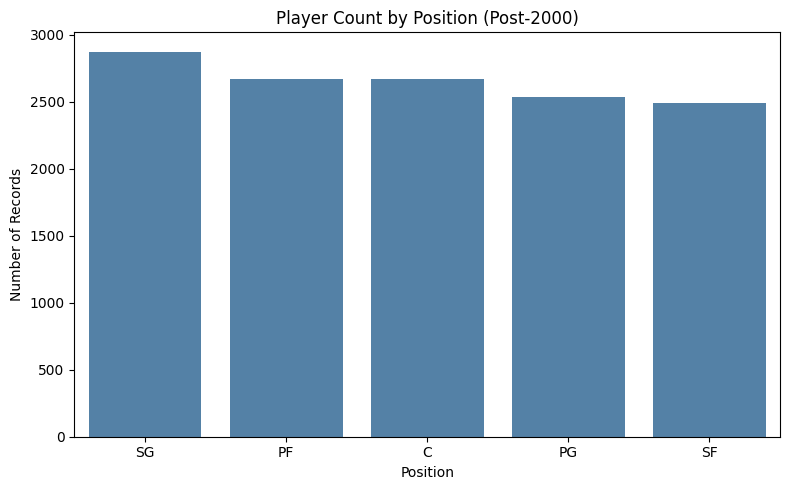

In [46]:
# 2A - Class Distribution
position_counts = df_modern['position'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=position_counts.index, y=position_counts.values, color='steelblue')
plt.title('Player Count by Position (Post-2000)')
plt.xlabel('Position')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

/var/folders/2k/t_2h7z4s787d87f1f9_7pgpm0000gn/T/ipykernel_58029/365859064.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_modern, x='position', y=feature,
/var/folders/2k/t_2h7z4s787d87f1f9_7pgpm0000gn/T/ipykernel_58029/365859064.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_modern, x='position', y=feature,
/var/folders/2k/t_2h7z4s787d87f1f9_7pgpm0000gn/T/ipykernel_58029/365859064.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_modern, x='position', y=feature,
/var/folders/2k/t_2h7z4s787d87f1f9_7pgpm000

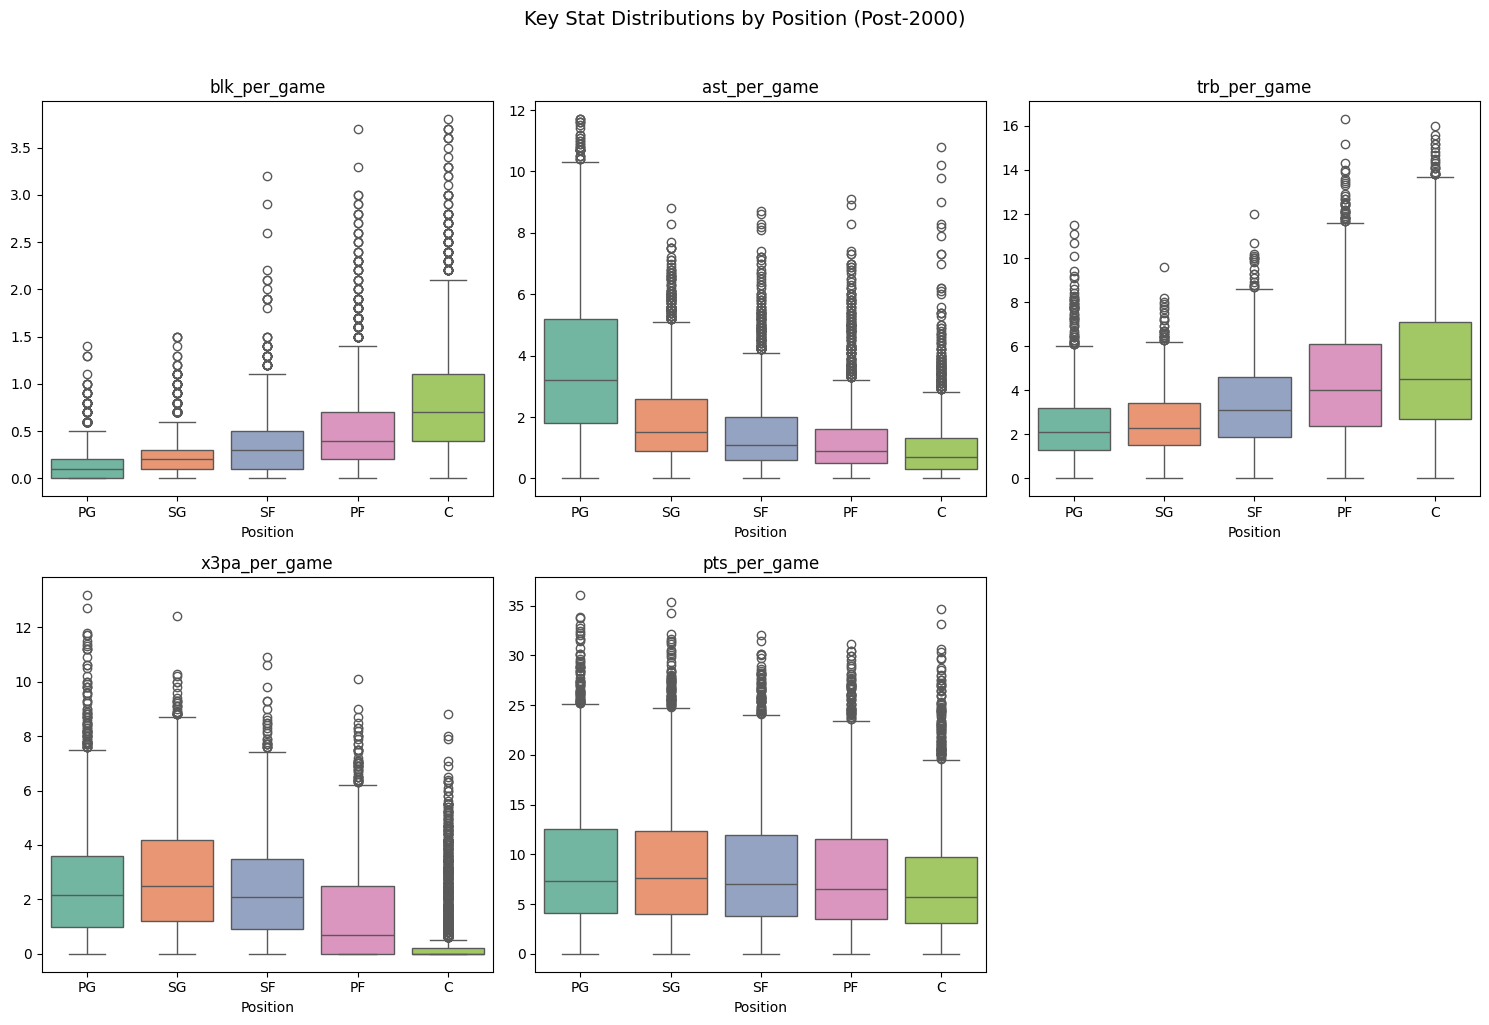

In [47]:
# 2B - Feature distributions by position
features = ['blk_per_game', 'ast_per_game', 'trb_per_game', 
            'x3pa_per_game', 'pts_per_game']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df_modern, x='position', y=feature, 
                order=['PG', 'SG', 'SF', 'PF', 'C'],
                palette='Set2', ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel('Position')
    axes[i].set_ylabel('')

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('Key Stat Distributions by Position (Post-2000)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

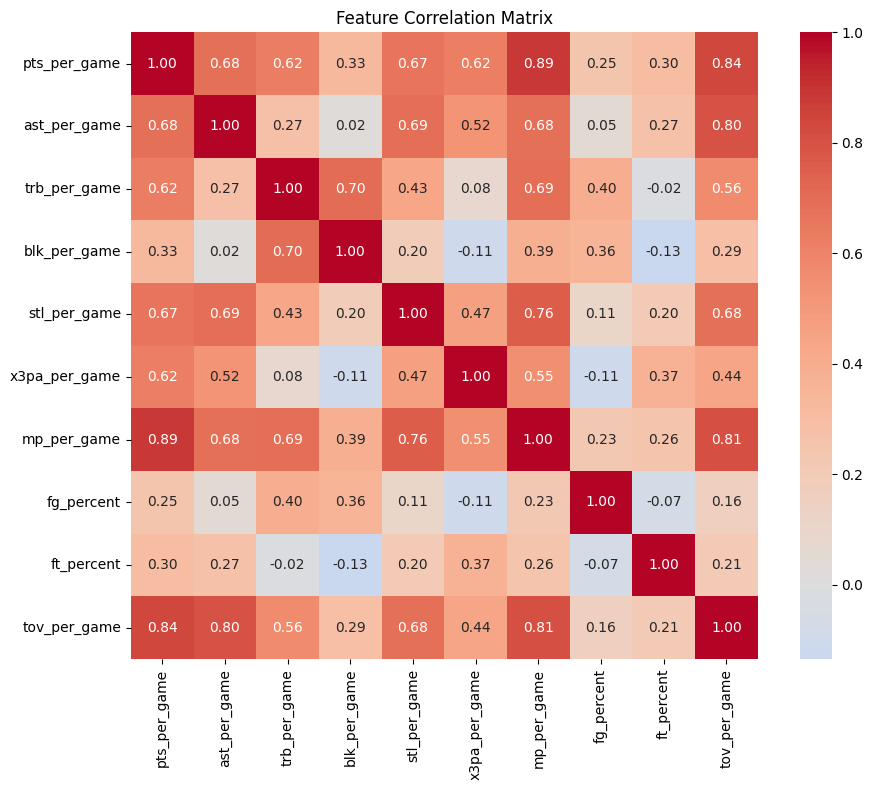

In [50]:
# 2C - Feature correlation matrix
features = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'blk_per_game',
            'stl_per_game', 'x3pa_per_game', 'mp_per_game', 'fg_percent',
            'ft_percent', 'tov_per_game']

corr_matrix = df_modern[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [52]:
# Step 1 - Apply minimum minutes filter (removes garbage time players)
df_model = df_modern[df_modern['mp_per_game'] >= 5].copy()
print("After minutes filter:", df_model.shape)

# Step 2 - Select the 10 features
features = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'blk_per_game',
            'stl_per_game', 'x3pa_per_game', 'mp_per_game', 'fg_percent',
            'ft_percent', 'tov_per_game']

X = df_model[features]
y = df_model['position']

# Step 3 - Encode position labels as numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nPosition encoding:")
for i, label in enumerate(le.classes_):
    print(f"  {label} -> {i}")

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y_encoded.shape)
print("\nAny nulls in X:", X.isnull().sum().sum())

After minutes filter: (12555, 37)

Position encoding:
  C -> 0
  PF -> 1
  PG -> 2
  SF -> 3
  SG -> 4
  nan -> 5

Feature matrix shape: (12555, 10)
Target vector shape: (12555,)

Any nulls in X: 0


In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

# Define classifiers
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Stratified 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Train and evaluate each
results = {}
for name, clf in classifiers.items():
    scores = cross_validate(clf, X, y_encoded, cv=cv,
                           scoring=['accuracy', 'f1_macro'])
    results[name] = {
        'accuracy': scores['test_accuracy'].mean(),
        'f1_macro': scores['test_f1_macro'].mean()
    }
    print(f"{name}:")
    print(f"  Accuracy: {scores['test_accuracy'].mean():.3f}")
    print(f"  Macro F1: {scores['test_f1_macro'].mean():.3f}\n")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Decision Tree:
  Accuracy: 0.530
  Macro F1: 0.495

Naive Bayes:
  Accuracy: 0.483
  Macro F1: 0.443



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Random Forest:
  Accuracy: 0.635
  Macro F1: 0.610



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


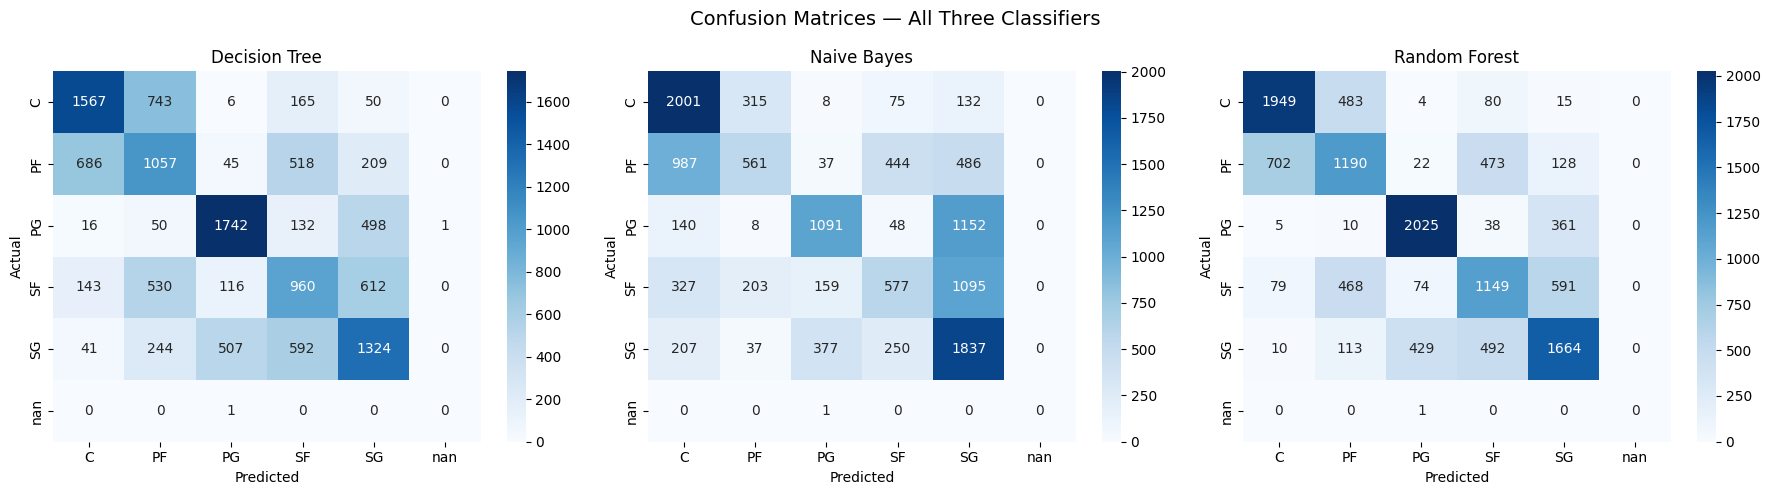

In [54]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

position_labels = le.classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, clf) in zip(axes, classifiers.items()):
    y_pred = cross_val_predict(clf, X, y_encoded, cv=cv)
    cm = confusion_matrix(y_encoded, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=position_labels,
                yticklabels=position_labels,
                ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Three Classifiers', fontsize=14)
plt.tight_layout()
plt.show()